# Домашнее задание: Урок 14 Линейная регрессия

**Задача:** Предсказать цену дома по его характеристикам

**Датасет:** California Housing Dataset (встроенный в sklearn)

---

## Цель задания

Повторить весь пайплайн машинного обучения:
1. Загрузка и изучение данных
2. Подготовка данных
3. Визуализация
4. Обучение модели
5. Оценка качества
6. Интерпретация результатов


---

# Часть 1: Загрузка данных и EDA

Загрузим встроенный датасет California Housing

In [2]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Настройки
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

print("Библиотеки загружены")

Библиотеки загружены


In [4]:
# Загрузка датасета California Housing
housing = fetch_california_housing(as_frame=True)

# Создаем DataFrame
df = housing.frame

print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} колонок")
print("\n" + "="*60)
df.head()

Размер датасета: 20640 строк, 9 колонок



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Описание признаков:

- **MedInc**: Медианный доход в районе (в $10,000)

- **HouseAge**: Средний возраст домов в районе (в годах)

- **AveRooms**: Среднее количество комнат на дом

- **AveBedrms**: Среднее количество спален на дом

- **Population**: Население района

- **AveOccup**: Среднее количество жильцов на дом

- **Latitude**: Широта

- **Longitude**: Долгота

- **MedHouseVal**: **Целевая переменная** — Медианная цена дома (в $100,000)

### Задание 1.1: Изучите данные

Напишите код для:
1. Показать информацию о датасете (.info())
2. Показать статистику по колонкам (.describe())
3. Проверить пропущенные значения (.isnull().sum())

In [19]:
df.describe()

df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


### Задание 1.2: Напишите выводы

Ответьте на вопросы:
1. Сколько всего домов в датасете?
2. Есть ли пропущенные значения?
3. Какая минимальная и максимальная цена дома (MedHouseVal)?
4. Какой признак имеет самый большой разброс значений?

**Ваши ответы:**  

1. 20640
2. Нет
3. Минимум: 0.14999
Максимум: 5.00001
4. Population


---

# Часть 2: Визуализация зависимостей

### Задание 2.1: Корреляция с целевой переменной (2 балла)

Постройте barplot корреляции всех признаков с MedHouseVal.

**Подсказка:**
```python
correlation = df.corr()['MedHouseVal'].sort_values(ascending=False)
```

In [11]:
correlation = df.corr()['MedHouseVal'].sort_values(ascending=False)
print(correlation)



MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


**Вопрос:** Какой признак имеет самую высокую корреляцию с ценой?

**Ваш ответ:** Средний доход (MedInc)



### Задание 2.2: Scatter plots

Постройте scatter plots для **трех признаков** с самой высокой корреляцией.

Формат: 3 графика в одном ряду (1 строка, 3 колонки)

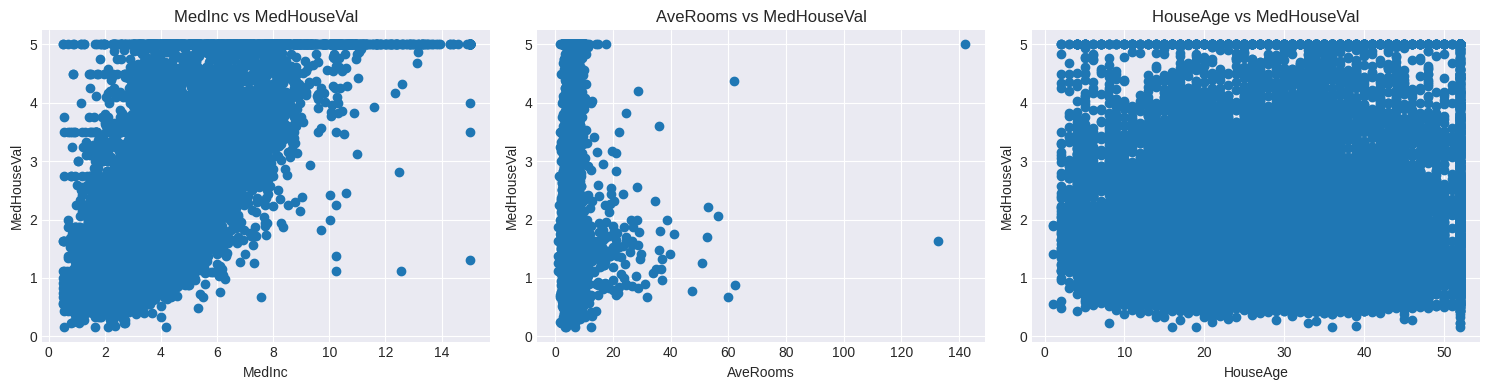

In [5]:
features = ['MedInc', 'AveRooms', 'HouseAge']
target = 'MedHouseVal'

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature in zip(axes, features):
    ax.scatter(df[feature], df[target])
    ax.set_xlabel(feature)
    ax.set_ylabel(target)
    ax.set_title(f'{feature} vs {target}')

plt.tight_layout()
plt.show()

**Вопрос:** Видна ли линейная зависимость на графиках?

**Ваш ответ:**  Да, видно.



---

# Часть 3: Подготовка данных

### Задание 3.1: Выбрать признаки и целевую переменную

Создайте:
- **X** — все признаки кроме MedHouseVal
- **y** — целевая переменная MedHouseVal

In [7]:
# Ваш код здесь
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (20640, 8)
y shape: (20640,)


### Задание 3.2: Разделить на Train и Test

Разделите данные:
- 80% для обучения (train)
- 20% для проверки (test)
- random_state = 42

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Размеры после разделения:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Размеры после разделения:
X_train: (16512, 8)
X_test: (4128, 8)
y_train: (16512,)
y_test: (4128,)


---

# Часть 4: Обучение модели

### Задание 4.1: Обучить Linear Regression

1. Создайте модель LinearRegression()
2. Обучите на train данных
3. Сделайте предсказания на train и test

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

### Задание 4.2: Первые предсказания

Покажите первые 5 предсказаний на test и сравните с реальными значениями

In [13]:
comparison = pd.DataFrame({
    'y_test_actual': y_test.values[:5],
    'y_test_predicted': y_test_pred[:5]
})

print(comparison)



   y_test_actual  y_test_predicted
0        0.47700          0.719123
1        0.45800          1.764017
2        5.00001          2.709659
3        2.18600          2.838926
4        2.78000          2.604657


---

# Часть 5: Оценка качества

### Задание 5.1: Посчитать метрики

Посчитайте для train и test:
1. RMSE
2. MAE
3. R²

Выведите в виде таблицы

In [14]:
def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

train_metrics = calculate_metrics(y_train, y_train_pred)
test_metrics = calculate_metrics(y_test, y_test_pred)

metrics_df = pd.DataFrame([train_metrics, test_metrics], columns=['RMSE', 'MAE', 'R2'], index=['Train', 'Test'])

print(metrics_df)



           RMSE       MAE        R2
Train  0.719676  0.528628  0.612551
Test   0.745581  0.533200  0.575788


### Задание 5.2: Интерпретация метрик

Ответьте на вопросы:

1. Какой RMSE получился на test? Что это означает?
2. Какой R² на test? Что это означает?
3. Сравните Train и Test метрики — есть ли переобучение?
4. Хорошо ли работает модель? Почему?

**Ваши ответы:**  
1. 0.745581. Сдвиг показывает, что предсказанные цены отличаются от реальных.
2.  0.575788. Сдвиг незначительный.
3. Разница небольшая, и сильного переобучения нет. Модель стабильна.
4. Модель не идеальна, но работает удовлетворительно.


---

# Часть 6: Интерпретация коэффициентов

### Задание 6.1: Показать коэффициенты

Выведите таблицу с коэффициентами для каждого признака и постройте barplot

      Feature  Coefficient
3   AveBedrms     0.783145
0      MedInc     0.448675
1    HouseAge     0.009724
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


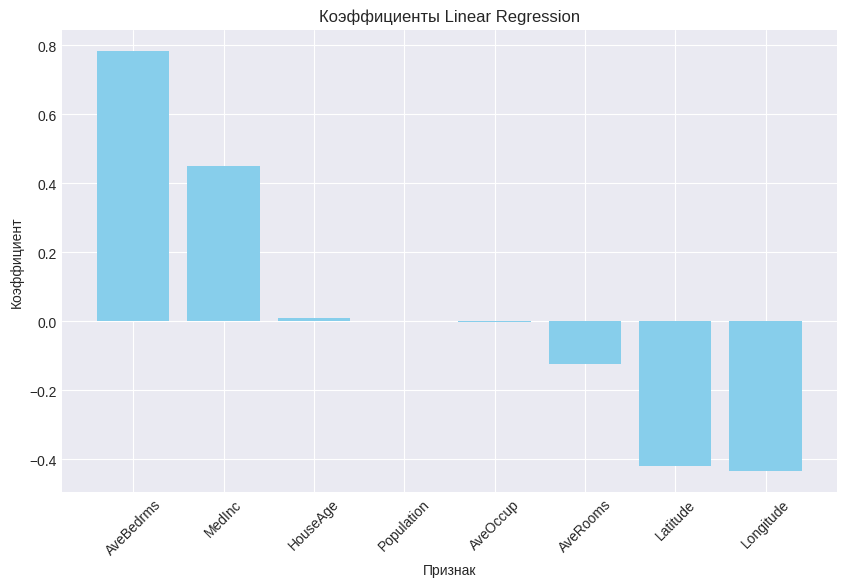

In [15]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df)

plt.figure(figsize=(10, 6))
plt.bar(coef_df['Feature'], coef_df['Coefficient'], color='skyblue')
plt.xticks(rotation=45)
plt.xlabel('Признак')
plt.ylabel('Коэффициент')
plt.title('Коэффициенты Linear Regression')
plt.show()


### Задание 6.2: Интерпретация

Ответьте на вопросы:

1. Какой признак имеет самый большой положительный коэффициент? Что это означает?
2. Какой признак имеет самый большой отрицательный коэффициент? Что это означает?
3. Объясните что означает коэффициент для MedInc (медианный доход)?
4. Имеет ли смысл Intercept (β₀) в этой задаче?

**Ваши ответы:**  

1. AveBedrms. Дома с большим количеством спален в среднем дороже.

2. Longitude. Дома, расположенные восточнее, имеют сниженную цену.

3. Чем выше доход, тем выше стоимость жилья.

4. Необязателен, но нужен для сравнения.

---

# Часть 7: Визуализация результатов

### Задание 7.1: Actual vs Predicted

Постройте scatter plot:
- X axis: реальные значения (y_test)
- Y axis: предсказанные значения (y_test_pred)
- Добавьте красную пунктирную линию y=x

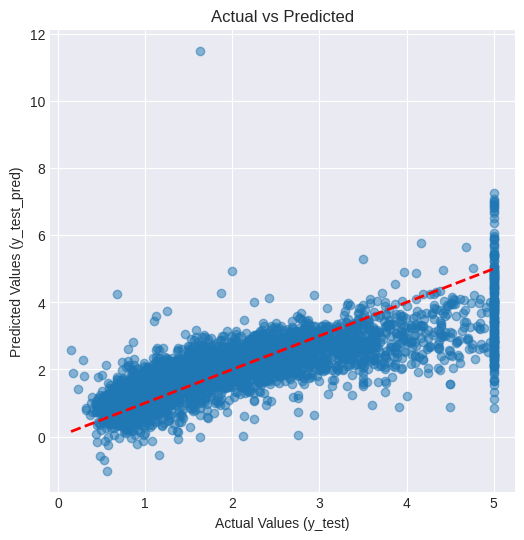

In [16]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Values (y_test)')
plt.ylabel('Predicted Values (y_test_pred)')
plt.title('Actual vs Predicted')
plt.grid(True)
plt.show()

### Задание 7.2: Распределение ошибок

Постройте histogram ошибок (residuals) на test:
- residuals = y_test - y_test_pred
- Добавьте вертикальную линию на x=0

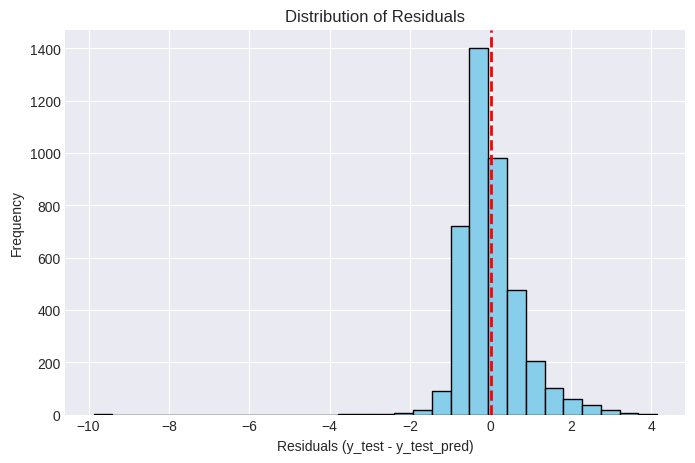

In [17]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals (y_test - y_test_pred)')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')
plt.grid(True)
plt.show()



**Вопрос:** Симметрично ли распределены ошибки вокруг нуля?

**Ваш ответ:**  Нет, ошибки распределены ассиметрично, модель завышает предсказания.



### Задание 8: Напишите итоговое резюме

Ответьте на вопросы:

1. **Какую задачу мы решали?**  
   (Что предсказывали, на каком датасете)

2. **Какие результаты получили?**  
   (R², RMSE — хорошие или плохие? Почему?)

3. **Какие признаки оказались самыми важными?**  
   (По коэффициентам)

4. **Соблюдаются ли условия Гаусса-Маркова?**  
   (По графикам: линейность, распределение ошибок и т.д.)

5. **Можно ли доверять этой модели в реальной жизни?**  
   (Почему да или нет?)

6. **Что можно улучшить?**  
   (Как минимум 2 идеи)

**Ваше резюме (5-10 предложений):**  
1. Мы предсказывали медианную стоимость жилья на основе статистики California Housing.

2. Результаты не идеальные, умеренно хорошие.

3. Самыми важными признаками по коэффициентам оказались AveBedrms, MedInc и географические координаты.

4. Условия соблюдаются, ошибки распределены примерно равномерно, но имеют ассиметрию.

5. Можно доверять для грубой оценки.

6. Можно улучшить добавив нелинейные признаки. Можно добавить более сложные модели. Можно провести работу с выбросами.

